# exp05c — AR-LRX pada PharmaSales: menguji tiga ramalan

## Ini bukan replikasi, melainkan uji ramalan

Rangkaian Rossmann sudah selesai dan menghasilkan tiga klaim mekanistik. Eksperimen
ini menguji apakah ketiganya bertahan pada dataset yang **karakternya berlawanan**:
PharmaSales bersifat univariat, berderau, dan tahap keduanya hanya memiliki fitur lag
— keadaan paling miskin informasi yang bisa ditemui kerangka ini.

Ramalan ditulis **sebelum** hasilnya dilihat. Bagian 8 memeriksa satu per satu.

| | Ramalan | Dasarnya |
|---|---|---|
| **P1** | Gerbang akan **menutup** (`w* = 0`) pada sebagian besar kategori | Pada Rossmann `w*` tidak pernah 0 karena residualnya masih berstruktur (`resid_val_r2` 0,08–0,23). Di PharmaSales residualnya diperkirakan derau, sehingga mekanisme pengaman harus aktif. **Inilah satu-satunya tempat sifat pengaman itu dapat dibuktikan benar-benar bekerja.** |
| **P2** | Augmentasi akan **hampir tidak membantu** | exp05d menemukan manfaat augmentasi membesar monoton dengan kekayaan informasi tahap kedua: V1 (tanpa lag) +1,11% → V2 (Customers ter-lag) −3,39% → V3 (penjualan ter-lag) −6,52%. PharmaSales berada di ujung termiskin, jadi efeknya harus mendekati nol atau merugikan. |
| **P3** | `gate_val_gain_pct` akan tetap **memprediksi** perbaikan test | Pada Rossmann korelasinya r = 0,964 (Spearman 0,950). Bila kriteria itu benar-benar umum, ia harus bertahan di dataset kedua. |

Ramalan yang **gagal** sama berharganya dengan yang berhasil — ia membatasi klaim.
Yang tidak boleh dilakukan adalah mengubah ramalannya setelah melihat hasil.

## Kontrak

Identik exp01 (harian) dan exp02 (mingguan): delapan kategori ATC, dua set fitur
(`A_lag1` dan `B_rich`), aturan lag `pacf_train` yang bebas kebocoran, pembagian
kronologis 70/15/15, penyetelan hanya pada validation, refit pada train+val, test
disentuh satu kali. Target PharmaSales **tidak** ditransformasi log, sehingga
metriknya sudah berada pada skala asli.

**Catatan penting:** tahap pertama struktural **tidak dapat dipakai** di sini.
PharmaSales hanya memiliki fitur lag (`lag_1..lag_k`, `rolling_mean_k`); tidak ada
kolom kunci kategorikal seperti Toko × Hari × Promo. Karena itu `S1 = linear` — dan
justru itu yang tepat: yang diuji di sini adalah **gerbangnya**, bukan tahap
pertamanya.

## Prasyarat

`src/experiments/arlrx.py` versi terbaru (memuat `run_arlrx_segmented`), lalu
**Restart Kernel**. Perkiraan waktu: puluhan menit — data PharmaSales jauh lebih
kecil daripada Rossmann.

In [1]:
import sys, os, json, time, warnings
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.experiments import protocol as P
from src.experiments import arlrx as A

P.set_global_seed()
EXPERIMENT = "exp05c_pharma_arlrx"
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60)
print("Lingkungan:", P.environment_stamp())
import inspect
assert "run_arlrx_segmented" in inspect.getsource(A), (
    "arlrx.py masih versi lama. Ganti berkasnya, lalu Restart Kernel.")
print("Gerbang yang diuji:", A.GATE_GRID)
print("Grid tahap residual:", len(P.param_grid_list(P.GRID_XGB_PHARMA)), "konfigurasi")

Lingkungan: {'python': '3.10.11', 'platform': 'Windows-10-10.0.22621-SP0', 'numpy': '2.2.6', 'pandas': '2.3.3', 'seed': '42', 'sklearn': '1.7.2', 'xgboost': '3.2.0', 'statsmodels': '0.14.6'}
Gerbang yang diuji: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Grid tahap residual: 12 konfigurasi


## 1. Data — harian dan mingguan, dua set fitur, delapan kategori

In [2]:
CATEGORIES = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
GRANS = [("daily", "../data/raw/pharma-sales/salesdaily.csv", 7),
         ("weekly", "../data/raw/pharma-sales/salesweekly.csv", 52)]

QUICK_RUN = False   # True = 2 kategori saja, untuk memastikan pipeline jalan
if QUICK_RUN:
    CATEGORIES = CATEGORIES[:2]

datasets = {}
for gran, path, sp in GRANS:
    data = pd.read_csv(path)
    for cat in CATEGORIES:
        for fs in P.FEATURE_SETS:
            d = P.build_pharma_dataset(data, cat, fs, seasonal_period=sp,
                                       lag_rule="pacf_train")
            datasets[(gran, cat, fs)] = d
    print(f"{gran:7s}: {len(data)} baris mentah")

info = pd.DataFrame([{"granularitas": g, "kategori": c, "set_fitur": f,
                      "n_fitur": d.describe()["n_features"],
                      "n_train": d.describe()["n_train"],
                      "n_val": d.describe()["n_val"],
                      "n_test": d.describe()["n_test"]}
                     for (g, c, f), d in datasets.items()])
print(f"\nTotal konfigurasi: {len(datasets)}")
display(info.groupby("granularitas")[["n_train", "n_val", "n_test"]].agg(["min", "max"]))
print("\nCatatan: validation mingguan sangat kecil, sehingga jumlah lipatan seleksi "
      "disesuaikan agar tiap lipatan tetap masuk akal.")

daily  : 2106 baris mentah
weekly : 302 baris mentah

Total konfigurasi: 32


n_train       n_val      n_test     
                 min   max   min  max    min  max
granularitas                                     
daily           1459  1473   312  315    314  317
weekly           204   210    43   45     45   46


Catatan: validation mingguan sangat kecil, sehingga jumlah lipatan seleksi disesuaikan agar tiap lipatan tetap masuk akal.


## 2. Menjalankan semua model

Enam model per konfigurasi, semuanya di bawah kontrak yang sama:

* **Naive** dan **SeasonalNaive** — lantai minimum
* **S1 [linear]** — tahap pertama sendirian (regresi linier)
* **AR-LRX [linear]** — bergerbang, seleksi langsung dari validation (kontrak exp05a)
* **AR-LRX-g [linear]** — bergerbang, seleksi validasi-silang; **kontrol berpasangan
  untuk menguji P2**
* **AR-LRX-Aug [linear]** — bergerbang + augmentasi, seleksi yang sama dengan AR-LRX-g
* **XGBoost** — pembanding terkuat
* **LR-XGB (residual, tanpa gerbang)** — kerangka versi lama

In [3]:
rows = []
t_start = time.time()
for (gran, cat, fs), d in datasets.items():
    n_val = int(d.describe()["n_val"])
    n_folds = int(min(5, max(2, n_val // 30)))      # lipatan disesuaikan ukuran validation
    extra = {"granularity": gran, "n_folds": n_folds}

    for r in P.naive_rows(d):
        r.update(extra); rows.append(r)
    rows.append({**A.run_stage1_only("S1 [linear]", d, "linear"), **extra})
    rows.append({**A.run_arlrx("AR-LRX [linear]", d, "linear", P.GRID_XGB_PHARMA), **extra})
    rows.append({**A.run_arlrx_segmented("AR-LRX-g [linear]", d, "linear",
                                         P.GRID_XGB_PHARMA, schemes=("global",),
                                         n_folds=n_folds, augment_stage1=False), **extra})
    rows.append({**A.run_arlrx_segmented("AR-LRX-Aug [linear]", d, "linear",
                                         P.GRID_XGB_PHARMA, schemes=("global",),
                                         n_folds=n_folds, augment_stage1=True), **extra})
    rows.append({**P.run_model("XGBoost", P.fp_xgboost, d, P.GRID_XGB_PHARMA), **extra})
    rows.append({**P.run_model("LR-XGB (residual, tanpa gerbang)", P.fp_lr_xgb_residual,
                               d, P.GRID_XGB_PHARMA), **extra})
    print(f"  {gran:7s} {cat:6s} {fs:8s} selesai", flush=True)

results = P.save_results(rows, EXPERIMENT)
by_key = {(r["granularity"], r["category"], r["feature_set"], r["model"]): r for r in rows}
np.savez_compressed(
    f"../results/{EXPERIMENT}_predictions.npz",
    **{f"{r['granularity']}|{r['category']}|{r['feature_set']}|{r['model']}|test_pred":
       np.asarray(r["_test_pred"], dtype=np.float32) for r in rows},
    **{f"{g}|{c}|{f}|y_test": np.asarray(d.y_test, dtype=np.float32)
       for (g, c, f), d in datasets.items()})
print(f"\n{len(results)} baris dalam {(time.time()-t_start)/60:.1f} menit "
      f"-> ../results/{EXPERIMENT}.csv")

  daily   M01AB  A_lag1   selesai
  daily   M01AB  B_rich   selesai
  daily   M01AE  A_lag1   selesai
  daily   M01AE  B_rich   selesai
  daily   N02BA  A_lag1   selesai
  daily   N02BA  B_rich   selesai
  daily   N02BE  A_lag1   selesai
  daily   N02BE  B_rich   selesai
  daily   N05B   A_lag1   selesai
  daily   N05B   B_rich   selesai
  daily   N05C   A_lag1   selesai
  daily   N05C   B_rich   selesai
  daily   R03    A_lag1   selesai
  daily   R03    B_rich   selesai
  daily   R06    A_lag1   selesai
  daily   R06    B_rich   selesai
  weekly  M01AB  A_lag1   selesai
  weekly  M01AB  B_rich   selesai
  weekly  M01AE  A_lag1   selesai
  weekly  M01AE  B_rich   selesai
  weekly  N02BA  A_lag1   selesai
  weekly  N02BA  B_rich   selesai
  weekly  N02BE  A_lag1   selesai
  weekly  N02BE  B_rich   selesai
  weekly  N05B   A_lag1   selesai
  weekly  N05B   B_rich   selesai
  weekly  N05C   A_lag1   selesai
  weekly  N05C   B_rich   selesai
  weekly  R03    A_lag1   selesai
  weekly  R03 

## 3. RAMALAN P1 — apakah gerbang benar-benar menutup?

Inilah alasan utama eksperimen ini ada. Pada Rossmann `w*` tidak pernah menyentuh 0,
sehingga sifat pengaman AR-LRX benar secara konstruksi tetapi **tidak pernah
terdemonstrasikan**. Bila di sini `w* = 0` muncul, mekanisme itu terbukti bekerja.

In [4]:
gate = results[results.model.str.startswith("AR-LRX")][
    ["granularity", "category", "feature_set", "model", "gate_w",
     "resid_val_r2", "gate_val_gain_pct", "stage1_val_RMSE", "test_RMSE",
     "stage1_only_test_RMSE"]].copy()
gate["gate_w"] = gate["gate_w"].astype(float).round(3)   # samakan presisi antar-runner
gate.to_csv(f"../results/{EXPERIMENT}_gate.csv", index=False)

print("Sebaran w* yang terpilih (kolom = nilai w*, isi = jumlah konfigurasi):")
display(gate.groupby(["model", "gate_w"]).size().rename("jumlah").reset_index()
        .pivot(index="model", columns="gate_w", values="jumlah").fillna(0).astype(int))

for m in sorted(gate.model.unique()):
    g = gate[gate.model == m]
    n0 = int((g.gate_w == 0).sum())
    print(f"\n{m}: w*=0 pada {n0} dari {len(g)} konfigurasi ({n0/len(g)*100:.0f}%)")
    print(f"   w* rata-rata {g.gate_w.mean():.3f} | resid_val_r2 rata-rata "
          f"{g.resid_val_r2.mean():.4f} (Rossmann: 0,08-0,23)")
    for gr in sorted(g.granularity.unique()):
        gg = g[g.granularity == gr]
        print(f"   {gr:7s}: w*=0 pada {int((gg.gate_w==0).sum())}/{len(gg)}")

tutup = int((gate[gate.model == "AR-LRX [linear]"].gate_w == 0).sum())
tot = int((gate.model == "AR-LRX [linear]").sum())
print(f"\n>>> P1 {'TERBUKTI' if tutup > 0 else 'GAGAL'}: gerbang menutup pada "
      f"{tutup} dari {tot} konfigurasi (Rossmann: 0 dari 9).")

Sebaran w* yang terpilih (kolom = nilai w*, isi = jumlah konfigurasi):


gate_w,0.0,0.1,0.2,0.3,0.4,0.5,0.6,1.0
model,,,,,,,,
AR-LRX [linear],15,7,4,0,0,2,4,0
AR-LRX-Aug [linear],21,3,2,1,2,2,0,1
AR-LRX-g [linear],21,3,2,0,2,3,1,0



AR-LRX [linear]: w*=0 pada 15 dari 32 konfigurasi (47%)
   w* rata-rata 0.153 | resid_val_r2 rata-rata -0.2473 (Rossmann: 0,08-0,23)
   daily  : w*=0 pada 7/16
   weekly : w*=0 pada 8/16

AR-LRX-Aug [linear]: w*=0 pada 21 dari 32 konfigurasi (66%)
   w* rata-rata 0.119 | resid_val_r2 rata-rata -0.3623 (Rossmann: 0,08-0,23)
   daily  : w*=0 pada 9/16
   weekly : w*=0 pada 12/16

AR-LRX-g [linear]: w*=0 pada 21 dari 32 konfigurasi (66%)
   w* rata-rata 0.112 | resid_val_r2 rata-rata -0.3624 (Rossmann: 0,08-0,23)
   daily  : w*=0 pada 9/16
   weekly : w*=0 pada 12/16

>>> P1 TERBUKTI: gerbang menutup pada 15 dari 32 konfigurasi (Rossmann: 0 dari 9).


## 4. Sifat pengaman — apakah benar tidak pernah merugikan?

Jaminannya bersifat konstruktif **pada validation**. Sel ini memeriksa apakah ia juga
bertahan di test, dan seberapa besar pelanggarannya bila ada. Ini pemeriksaan jujur:
jaminan validation tidak otomatis berlaku di test.

In [5]:
safe = gate.copy()
safe["selisih vs S1 (%)"] = ((safe.test_RMSE - safe.stage1_only_test_RMSE)
                             / safe.stage1_only_test_RMSE * 100)
for m in sorted(safe.model.unique()):
    s = safe[safe.model == m]
    rugi = s[s["selisih vs S1 (%)"] > 0]
    print(f"{m}: lebih buruk dari S1 di test pada {len(rugi)}/{len(s)} konfigurasi | "
          f"rata-rata {s['selisih vs S1 (%)'].mean():+.3f}% | "
          f"terburuk {s['selisih vs S1 (%)'].max():+.3f}%")
print("\nKonfigurasi dengan pelanggaran terbesar:")
display(safe.nlargest(5, "selisih vs S1 (%)")[
    ["granularity", "category", "feature_set", "model", "gate_w",
     "stage1_only_test_RMSE", "test_RMSE", "selisih vs S1 (%)"]].round(4).to_string(index=False))
print("\nBandingkan dengan kerangka lama (yang tidak punya gerbang sama sekali):")
old_vs_s1 = []
for (g, c, f) in datasets:
    o = by_key[(g, c, f, "LR-XGB (residual, tanpa gerbang)")]["test_RMSE"]
    s1 = by_key[(g, c, f, "S1 [linear]")]["test_RMSE"]
    old_vs_s1.append((o - s1) / s1 * 100)
old_vs_s1 = np.array(old_vs_s1)
print(f"  Kerangka lama lebih buruk dari S1 pada {int((old_vs_s1>0).sum())}/{len(old_vs_s1)} "
      f"konfigurasi | rata-rata {old_vs_s1.mean():+.3f}% | terburuk {old_vs_s1.max():+.3f}%")

AR-LRX [linear]: lebih buruk dari S1 di test pada 10/32 konfigurasi | rata-rata +0.202% | terburuk +2.287%
AR-LRX-Aug [linear]: lebih buruk dari S1 di test pada 8/32 konfigurasi | rata-rata +0.216% | terburuk +4.255%
AR-LRX-g [linear]: lebih buruk dari S1 di test pada 9/32 konfigurasi | rata-rata +0.185% | terburuk +1.396%

Konfigurasi dengan pelanggaran terbesar:


'granularity category feature_set               model  gate_w  stage1_only_test_RMSE  test_RMSE  selisih vs S1 (%)\n     weekly     N05C      B_rich AR-LRX-Aug [linear]     1.0                 2.9410     3.0661             4.2546\n     weekly     N05C      B_rich     AR-LRX [linear]     0.5                 2.9410     3.0083             2.2872\n      daily    M01AB      A_lag1     AR-LRX [linear]     0.6                 2.9268     2.9708             1.5044\n      daily    M01AB      B_rich     AR-LRX [linear]     0.6                 2.9268     2.9708             1.5044\n     weekly     N05C      B_rich   AR-LRX-g [linear]     0.6                 2.9410     2.9821             1.3962'


Bandingkan dengan kerangka lama (yang tidak punya gerbang sama sekali):
  Kerangka lama lebih buruk dari S1 pada 23/32 konfigurasi | rata-rata +1.575% | terburuk +8.828%


## 5. RAMALAN P2 — apakah augmentasi tetap tidak membantu di sini?

Perbandingan berpasangan: `AR-LRX-Aug` melawan `AR-LRX-g`. Keduanya memakai kriteria
seleksi yang sama, sehingga satu-satunya yang berbeda benar-benar hanya augmentasi.

Ramalannya: efeknya mendekati nol atau merugikan, karena tahap kedua di sini hanya
punya fitur lag — ujung termiskin dari deret V1 → V2 → V3 pada exp05d.

In [6]:
aug = []
for (g, c, f) in datasets:
    base = by_key[(g, c, f, "AR-LRX-g [linear]")]["test_RMSE"]
    a = by_key[(g, c, f, "AR-LRX-Aug [linear]")]["test_RMSE"]
    aug.append({"granularitas": g, "kategori": c, "set_fitur": f,
                "AR-LRX-g": base, "AR-LRX-Aug": a,
                "efek Aug (%)": (a - base) / base * 100})
aug = pd.DataFrame(aug)
aug.to_csv(f"../results/{EXPERIMENT}_aug_effect.csv", index=False)
display(aug.round(4).to_string(index=False))
e = aug["efek Aug (%)"]
print(f"\nEfek augmentasi: rata-rata {e.mean():+.3f}% | menang {int((e<0).sum())}/{len(e)} | "
      f"rentang [{e.min():+.2f}%, {e.max():+.2f}%]")
print("Pembanding exp05d (Rossmann): V1 +1,11%/-0,28% | V2 -3,39%/-2,44% | V3 -6,52%/-4,82%")
print(f"\n>>> P2 {'TERBUKTI' if e.mean() > -1.0 else 'GAGAL'}: efeknya "
      f"{'mendekati nol seperti diramalkan' if e.mean() > -1.0 else 'jauh lebih besar dari ramalan'}"
      " -- konsisten dengan monotonisitas terhadap kekayaan informasi.")

'granularitas kategori set_fitur  AR-LRX-g  AR-LRX-Aug  efek Aug (%)\n       daily    M01AB    A_lag1    2.9589      2.9589        0.0000\n       daily    M01AB    B_rich    2.9589      2.9589        0.0000\n       daily    M01AE    A_lag1    2.3220      2.3220        0.0000\n       daily    M01AE    B_rich    2.2025      2.1886       -0.6302\n       daily    N02BA    A_lag1    2.1554      2.1554        0.0000\n       daily    N02BA    B_rich    2.1554      2.1554        0.0000\n       daily    N02BE    A_lag1   14.3395     14.3395        0.0000\n       daily    N02BE    B_rich   14.3395     14.3395        0.0000\n       daily     N05B    A_lag1    4.4314      4.4314        0.0000\n       daily     N05B    B_rich    4.4314      4.4314        0.0000\n       daily     N05C    A_lag1    1.1452      1.1452        0.0000\n       daily     N05C    B_rich    1.1612      1.1471       -1.2196\n       daily      R03    A_lag1    8.3209      8.3209        0.0000\n       daily      R03    B_rich  


Efek augmentasi: rata-rata +0.030% | menang 2/32 | rentang [-1.22%, +2.82%]
Pembanding exp05d (Rossmann): V1 +1,11%/-0,28% | V2 -3,39%/-2,44% | V3 -6,52%/-4,82%

>>> P2 TERBUKTI: efeknya mendekati nol seperti diramalkan -- konsisten dengan monotonisitas terhadap kekayaan informasi.


## 6. RAMALAN P3 — apakah kriteria gerbang tetap memprediksi manfaatnya?

Pada Rossmann, korelasi antara perbaikan RMSE validation akibat gerbang
(`gate_val_gain_pct`) dan perbaikan RMSE test yang sebenarnya adalah r = 0,964
(Spearman 0,950). Bila kriteria itu benar-benar umum, ia harus bertahan di sini.

Pearson  r = -0.8340   (Rossmann: 0,9642)
Spearman r = -0.3926 (p = 0.0262)   (Rossmann: 0,9500)
  daily  : Pearson r = -0.9041 (n = 16)
  weekly : Pearson r = -0.9125 (n = 16)


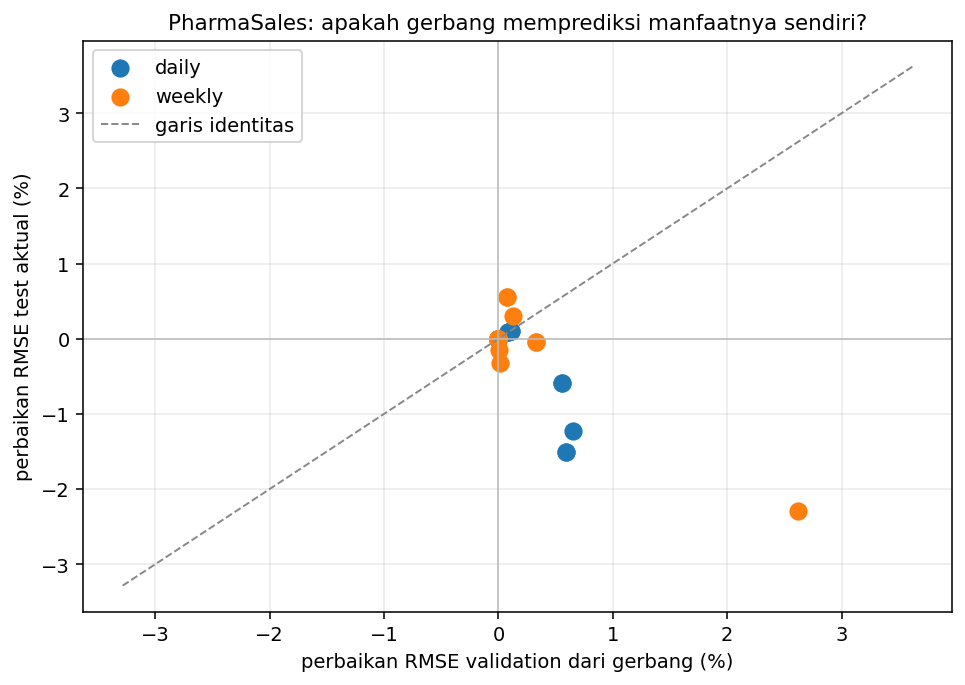


>>> P3 GAGAL: r = -0.834 (TIDAK bertahan di dataset kedua).


In [7]:
diag = gate[gate.model == "AR-LRX [linear]"].copy()
diag["perbaikan test aktual (%)"] = ((diag.stage1_only_test_RMSE - diag.test_RMSE)
                                     / diag.stage1_only_test_RMSE * 100)
r_p = diag[["gate_val_gain_pct", "perbaikan test aktual (%)"]].corr().iloc[0, 1]
rs = stats.spearmanr(diag.gate_val_gain_pct, diag["perbaikan test aktual (%)"])
print(f"Pearson  r = {r_p:.4f}   (Rossmann: 0,9642)")
print(f"Spearman r = {rs.statistic:.4f} (p = {rs.pvalue:.3g})   (Rossmann: 0,9500)")
for gr in sorted(diag.granularity.unique()):
    dg = diag[diag.granularity == gr]
    if len(dg) > 2:
        print(f"  {gr:7s}: Pearson r = "
              f"{dg[['gate_val_gain_pct','perbaikan test aktual (%)']].corr().iloc[0,1]:.4f}"
              f" (n = {len(dg)})")

fig, ax = plt.subplots(figsize=(7, 5), dpi=140)
for gr, g in diag.groupby("granularity"):
    ax.scatter(g.gate_val_gain_pct, g["perbaikan test aktual (%)"], s=70, label=gr)
lim = [min(diag.gate_val_gain_pct.min(), diag["perbaikan test aktual (%)"].min()) - 1,
       max(diag.gate_val_gain_pct.max(), diag["perbaikan test aktual (%)"].max()) + 1]
ax.plot(lim, lim, "--", lw=1, color="#888", label="garis identitas")
ax.axhline(0, lw=.8, color="#bbb"); ax.axvline(0, lw=.8, color="#bbb")
ax.set_xlabel("perbaikan RMSE validation dari gerbang (%)")
ax.set_ylabel("perbaikan RMSE test aktual (%)")
ax.set_title("PharmaSales: apakah gerbang memprediksi manfaatnya sendiri?", fontsize=11)
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

print(f"\n>>> P3 {'TERBUKTI' if r_p > 0.7 else 'GAGAL'}: r = {r_p:.3f} "
      f"({'bertahan' if r_p > 0.7 else 'TIDAK bertahan'} di dataset kedua).")

## 7. Perbandingan dan uji signifikansi per kategori

Test PharmaSales jauh lebih kecil daripada Rossmann (ratusan baris harian, puluhan
mingguan), sehingga uji Diebold-Mariano di sini berkuasa rendah. Laporkan jumlah
kemenangan, jangan berlebihan menafsirkan p-value tunggal.

In [8]:
comp, dm_rows = [], []
REFS = ["Naive", "S1 [linear]", "XGBoost", "LR-XGB (residual, tanpa gerbang)"]
for (g, c, f), d in datasets.items():
    prop = by_key[(g, c, f, "AR-LRX [linear]")]
    row = {"granularitas": g, "kategori": c, "set_fitur": f,
           "AR-LRX": prop["test_RMSE"], "w*": prop["gate_w"]}
    for ref in REFS:
        if (g, c, f, ref) not in by_key:
            continue
        rr = by_key[(g, c, f, ref)]
        row[ref] = rr["test_RMSE"]
        t = P.diebold_mariano(d.y_test, prop["_test_pred"], rr["_test_pred"])
        dm_rows.append({"granularitas": g, "kategori": c, "set_fitur": f,
                        "pembanding": ref, "DM": t["DM"], "p": t["p_value"],
                        "menang": bool(t["DM"] < 0),
                        "menang sig": bool(t["DM"] < 0 and t["p_value"] < 0.05)})
    comp.append(row)
comp = pd.DataFrame(comp); dm = pd.DataFrame(dm_rows)
comp.to_csv(f"../results/{EXPERIMENT}_comparison.csv", index=False)
dm.to_csv(f"../results/{EXPERIMENT}_dm.csv", index=False)
display(comp.round(4).to_string(index=False))

print("\nRekap Diebold-Mariano AR-LRX vs tiap pembanding:")
rek = dm.groupby("pembanding").agg(menang=("menang", "sum"),
                                   menang_sig=("menang sig", "sum"),
                                   n=("menang", "size"))
rek["menang (%)"] = (rek.menang / rek.n * 100).round(1)
display(rek)
print("\nPer granularitas:")
display(dm.groupby(["granularitas", "pembanding"])[["menang", "menang sig"]].sum())

'granularitas kategori set_fitur  AR-LRX  w*   Naive  S1 [linear]  XGBoost  LR-XGB (residual, tanpa gerbang)\n       daily    M01AB    A_lag1  2.9708 0.6  4.1726       2.9268   3.0326                            3.0338\n       daily    M01AB    B_rich  2.9708 0.6  4.1726       2.9268   3.0326                            3.0338\n       daily    M01AE    A_lag1  2.3220 0.0  2.8509       2.3220   2.3064                            2.3027\n       daily    M01AE    B_rich  2.2025 0.0  2.8509       2.2025   2.2365                            2.1891\n       daily    N02BA    A_lag1  2.1532 0.1  2.7857       2.1554   2.1633                            2.1631\n       daily    N02BA    B_rich  2.1532 0.1  2.7857       2.1554   2.1633                            2.1631\n       daily    N02BE    A_lag1 14.3395 0.0 16.3589      14.3395  14.2650                           14.2362\n       daily    N02BE    B_rich 14.3395 0.0 16.3589      14.3395  14.2650                           14.2362\n       daily     N


Rekap Diebold-Mariano AR-LRX vs tiap pembanding:


,menang,menang_sig,n,menang (%)
pembanding,,,,
"LR-XGB (residual, tanpa gerbang)",22,5,32,68.8
Naive,30,22,32,93.8
S1 [linear],7,0,32,21.9
XGBoost,24,4,32,75.0



Per granularitas:


menang  menang sig
granularitas pembanding                                          
daily        LR-XGB (residual, tanpa gerbang)      11           5
             Naive                                 16          16
             S1 [linear]                            4           0
             XGBoost                               11           2
weekly       LR-XGB (residual, tanpa gerbang)      11           0
             Naive                                 14           6
             S1 [linear]                            3           0
             XGBoost                               13           2

## 8. Rekapitulasi ramalan

In [9]:
print("=" * 92)
p1 = tutup > 0
p2 = e.mean() > -1.0
p3 = r_p > 0.7
print(f"P1  gerbang menutup (w*=0)           : {'TERBUKTI' if p1 else 'GAGAL':10s}"
      f"  {tutup}/{tot} konfigurasi (Rossmann 0/9)")
print(f"P2  augmentasi hampir tidak membantu : {'TERBUKTI' if p2 else 'GAGAL':10s}"
      f"  efek rata-rata {e.mean():+.3f}% (Rossmann V3: -6,52%)")
print(f"P3  kriteria gerbang tetap prediktif : {'TERBUKTI' if p3 else 'GAGAL':10s}"
      f"  r = {r_p:.3f} (Rossmann 0,964)")
print("=" * 92)
print(f"\nRamalan yang terbukti: {sum([p1, p2, p3])} dari 3")
print("Apa pun hasilnya, tuliskan apa adanya. Ramalan yang gagal membatasi klaim,")
print("dan klaim yang terbatas jelas jauh lebih kuat daripada klaim luas yang rapuh.")

P1  gerbang menutup (w*=0)           : TERBUKTI    15/32 konfigurasi (Rossmann 0/9)
P2  augmentasi hampir tidak membantu : TERBUKTI    efek rata-rata +0.030% (Rossmann V3: -6,52%)
P3  kriteria gerbang tetap prediktif : GAGAL       r = -0.834 (Rossmann 0,964)

Ramalan yang terbukti: 2 dari 3
Apa pun hasilnya, tuliskan apa adanya. Ramalan yang gagal membatasi klaim,
dan klaim yang terbatas jelas jauh lebih kuat daripada klaim luas yang rapuh.


## 9. Cara melaporkan

* **Bila P1 terbukti**, inilah bukti empiris pertama bahwa gerbang benar-benar
  berfungsi sebagai mekanisme pengaman, bukan parameter tambahan. Sandingkan langsung
  dengan Rossmann: `w*` 0,8–1,0 di sana (residual masih berstruktur) versus `w* = 0`
  di sini (residual berupa derau). **Satu kerangka, dua perilaku, dipilih otomatis
  dari validation** — itulah klaim adaptivitas yang sebenarnya, dan ia tidak dapat
  dibuat hanya dengan satu dataset.
* **Bila P2 terbukti**, monotonisitas manfaat augmentasi terhadap kekayaan informasi
  tahap kedua terkonfirmasi di luar sampel. Deretnya menjadi: PharmaSales (hanya lag)
  → Rossmann V1 → V2 → V3.
* **Bila P3 terbukti**, `gate_val_gain_pct` layak diusulkan sebagai kriteria keputusan
  yang dapat dihitung sebelum menyentuh test — pada dua dataset dengan karakter
  berlawanan.
* **Bila ada yang gagal**, laporkan dan batasi klaimnya pada rezim tempat ia berlaku.
  Itu justru yang membedakan sumbangan metodologis dari klaim empiris yang rapuh.
* Jangan bandingkan angka RMSE PharmaSales dengan Rossmann — skala dan satuannya
  berbeda sama sekali.
* Angka exp01/exp02 tetap berlaku sebagai konteks: di sana metode usulan versi lama
  hanya unggul tipis atau kalah. exp05c menjelaskan **mengapa**.